# ⚡ FitPulse — Fitbit Data: EDA, SQL & App Data Builder
**Bellabeat / Strava Fitness Case Study**

Is notebook me:
1. Saari **clean CSV files** load hoti hain
2. Data quality checks + **EDA** (Python: pandas, matplotlib, seaborn)
3. **SQL analysis** (SQLite)
4. Streamlit app ke liye light-weight **`data/` folder** banta hai

> Clean CSV files ko `clean_data/` folder me rakho (ya neeche `CLEAN` path badlo).

In [1]:
import os, sqlite3
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.titlesize": 13})

CLEAN = "clean_data"      # folder with the *_clean.csv files
OUT   = "data"            # folder created for the Streamlit app
os.makedirs(OUT, exist_ok=True)
WD = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

## 1. Load clean data

In [2]:
rd = lambda f, **k: pd.read_csv(f"{CLEAN}/{f}", dtype={"Id": str}, **k)

daily  = rd("dailyActivity_clean.csv", parse_dates=["Date"])
sleep  = rd("sleepDay_clean.csv", parse_dates=["Date"])
weight = rd("weightLogInfo_clean.csv", parse_dates=["Date"])
hs = rd("hourlySteps_clean.csv", parse_dates=["ActivityHour"])
hc = rd("hourlyCalories_clean.csv", parse_dates=["ActivityHour"])
hi = rd("hourlyIntensities_clean.csv", parse_dates=["ActivityHour"])
hr_sec = rd("heartrate_seconds_clean.csv", parse_dates=["Time"])
min_sleep = rd("minuteSleep_clean.csv", parse_dates=["DateTime"])
mets = rd("minuteMETsNarrow_clean.csv", parse_dates=["ActivityMinute"])

hourly = hs.merge(hc, on=["Id","ActivityHour"]).merge(hi, on=["Id","ActivityHour"])
hourly["Date"] = hourly["ActivityHour"].dt.normalize()
hourly["Hour"] = hourly["ActivityHour"].dt.hour

overview = pd.DataFrame({
    "table": ["daily","sleep","weight","hourly","heart rate (sec)","minute sleep","METs (min)"],
    "rows":  [len(x) for x in (daily, sleep, weight, hourly, hr_sec, min_sleep, mets)],
    "users": [x["Id"].nunique() for x in (daily, sleep, weight, hourly, hr_sec, min_sleep, mets)]})
overview

,table,rows,users
0,daily,940,33
1,sleep,410,24
2,weight,67,8
3,hourly,22099,33
4,heart rate (sec),2483658,14
5,minute sleep,187978,24
6,METs (min),1325580,33


## 2. Data quality checks

In [3]:
checks = {}
for name, df, keys in [("daily", daily, ["Id","Date"]), ("sleep", sleep, ["Id","Date"]),
                       ("weight", weight, ["Id","Date"]), ("hourly", hourly, ["Id","ActivityHour"]),
                       ("heart rate", hr_sec, ["Id","Time"])]:
    checks[name] = {"rows": len(df), "nulls": int(df.isna().sum().sum()), "duplicate keys": int(df.duplicated(keys).sum())}
pd.DataFrame(checks).T

,rows,nulls,duplicate keys
daily,940,0,0
sleep,410,0,0
weight,67,0,0
hourly,22099,0,0
heart rate,2483658,0,0


## 3. EDA — Daily activity

In [4]:
daily["Weekday"] = pd.Categorical(daily["Date"].dt.day_name(), WD, ordered=True)
daily["SedentaryHours"] = daily["SedentaryMinutes"] / 60
daily[["TotalSteps","TotalDistance","Calories","SedentaryMinutes","VeryActiveMinutes","FairlyActiveMinutes","LightlyActiveMinutes"]].describe().round(1)

,TotalSteps,TotalDistance,Calories,SedentaryMinutes,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes
count,940.0,940.0,940.0,940.0,940.0,940.0,940.0
mean,7637.9,5.5,2303.6,991.2,21.2,13.6,192.8
std,5087.2,3.9,718.2,301.3,32.8,20.0,109.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,3789.8,2.6,1828.5,729.8,0.0,0.0,127.0
50%,7405.5,5.2,2134.0,1057.5,4.0,6.0,199.0
75%,10727.0,7.7,2793.2,1229.5,32.0,19.0,264.0
max,36019.0,28.0,4900.0,1440.0,210.0,143.0,518.0


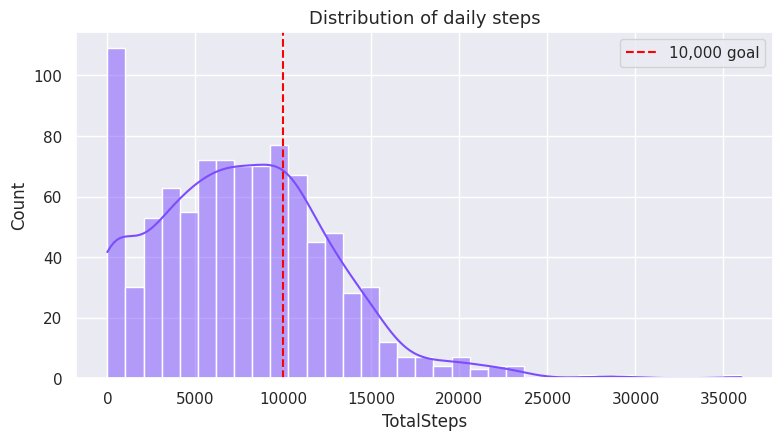

Average steps: 7,638 | days >= 10k: 32.2%


In [5]:
sns.histplot(daily["TotalSteps"], bins=35, kde=True, color="#7C4DFF")
plt.axvline(10000, color="red", ls="--", label="10,000 goal"); plt.legend()
plt.title("Distribution of daily steps"); plt.show()
print(f"Average steps: {daily['TotalSteps'].mean():,.0f} | days >= 10k: {(daily['TotalSteps']>=10000).mean()*100:.1f}%")

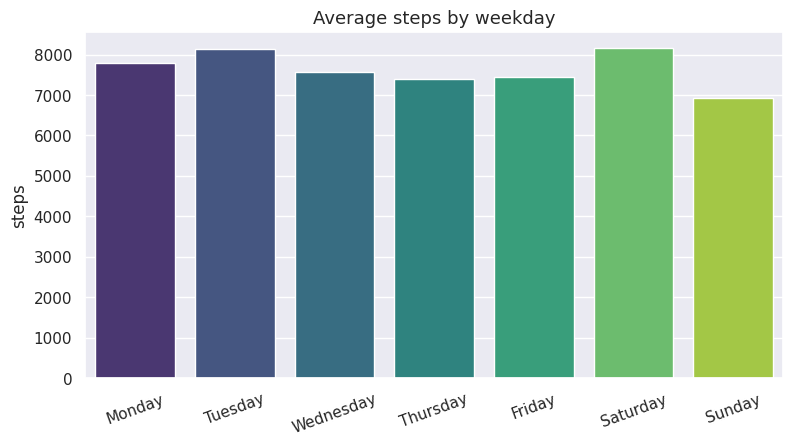

In [6]:
wk = daily.groupby("Weekday", observed=True)["TotalSteps"].mean().reindex(WD)
sns.barplot(x=wk.index, y=wk.values, hue=wk.index, legend=False, palette="viridis")
plt.title("Average steps by weekday"); plt.ylabel("steps"); plt.xlabel(""); plt.xticks(rotation=20); plt.show()

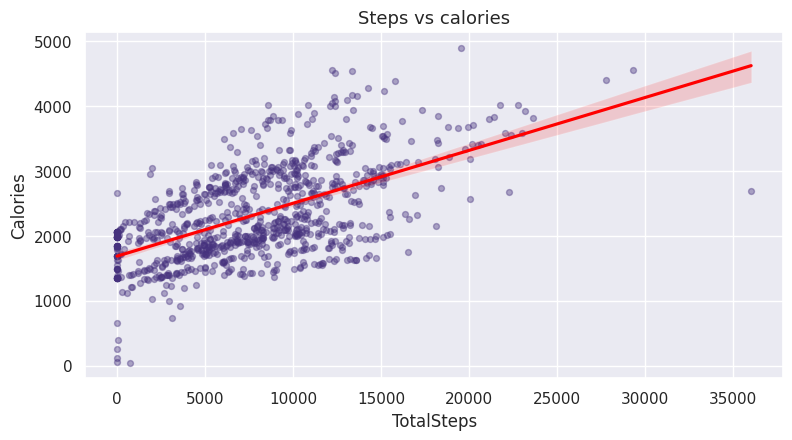

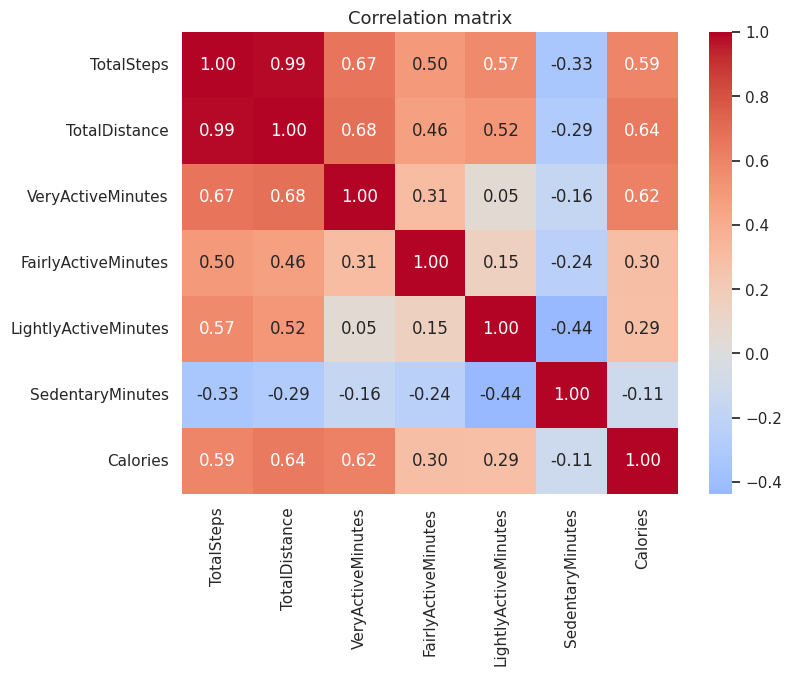

In [7]:
sns.regplot(data=daily[~((daily.TotalSteps==0)&(daily.Calories==0))], x="TotalSteps", y="Calories",
            scatter_kws={"alpha":.4,"s":18}, line_kws={"color":"red"})
plt.title("Steps vs calories"); plt.show()
cols = ["TotalSteps","TotalDistance","VeryActiveMinutes","FairlyActiveMinutes","LightlyActiveMinutes","SedentaryMinutes","Calories"]
plt.figure(figsize=(8,6)); sns.heatmap(daily[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()

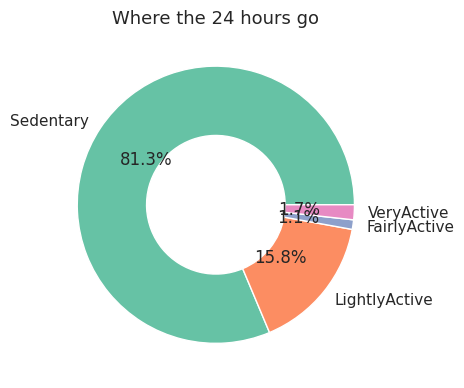

In [8]:
m = daily[["SedentaryMinutes","LightlyActiveMinutes","FairlyActiveMinutes","VeryActiveMinutes"]].mean()
plt.pie(m, labels=[c.replace("Minutes","") for c in m.index], autopct="%1.1f%%", colors=sns.color_palette("Set2"), wedgeprops=dict(width=.5))
plt.title("Where the 24 hours go"); plt.show()

## 4. EDA — Hourly pattern

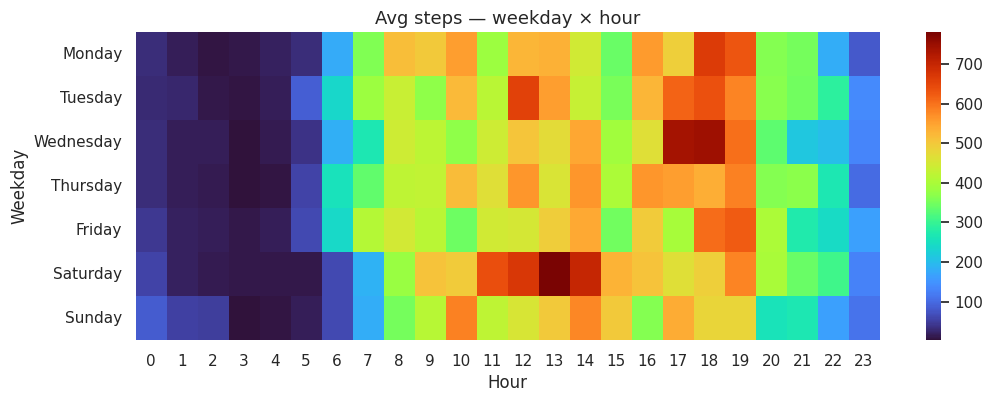

Peak hour: 18


In [9]:
hourly["Weekday"] = pd.Categorical(hourly["Date"].dt.day_name(), WD, ordered=True)
heat = hourly.pivot_table(index="Weekday", columns="Hour", values="StepTotal", aggfunc="mean", observed=True).reindex(WD)
plt.figure(figsize=(12,4)); sns.heatmap(heat, cmap="turbo"); plt.title("Avg steps — weekday × hour"); plt.show()
print("Peak hour:", hourly.groupby("Hour")["StepTotal"].mean().idxmax())

## 5. EDA — Sedentary behaviour

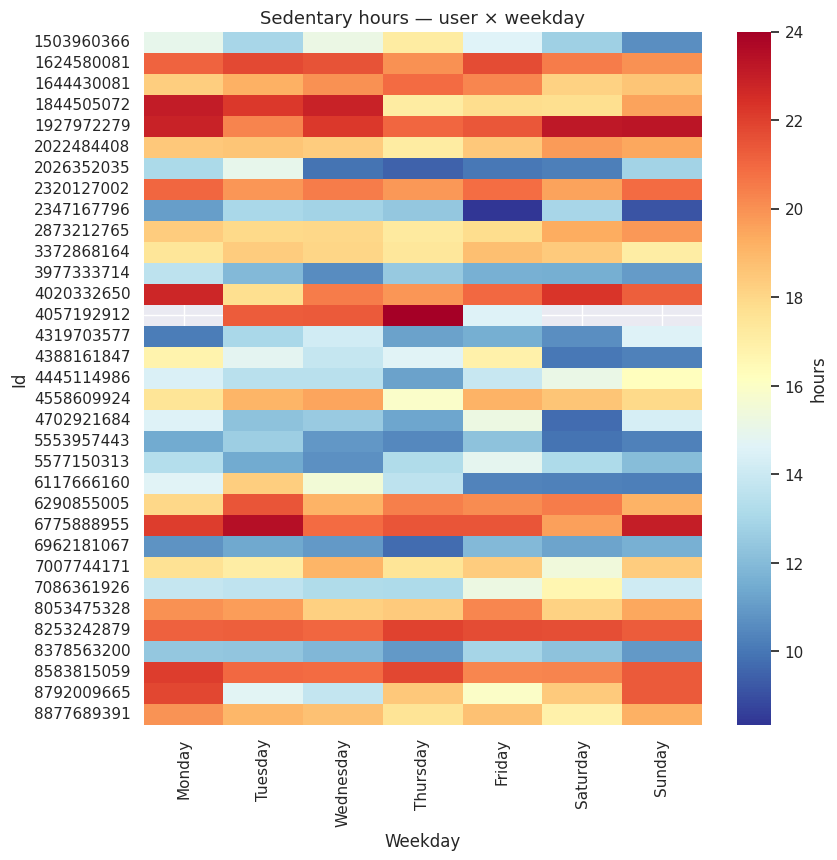

In [10]:
u = daily.pivot_table(index="Id", columns="Weekday", values="SedentaryHours", aggfunc="mean", observed=True)[WD]
plt.figure(figsize=(9,9)); sns.heatmap(u, cmap="RdYlBu_r", cbar_kws={"label":"hours"}); plt.title("Sedentary hours — user × weekday"); plt.show()

## 6. EDA — Sleep

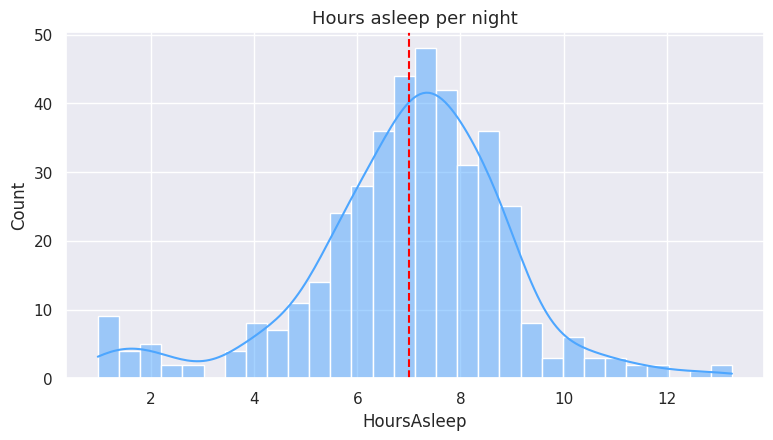

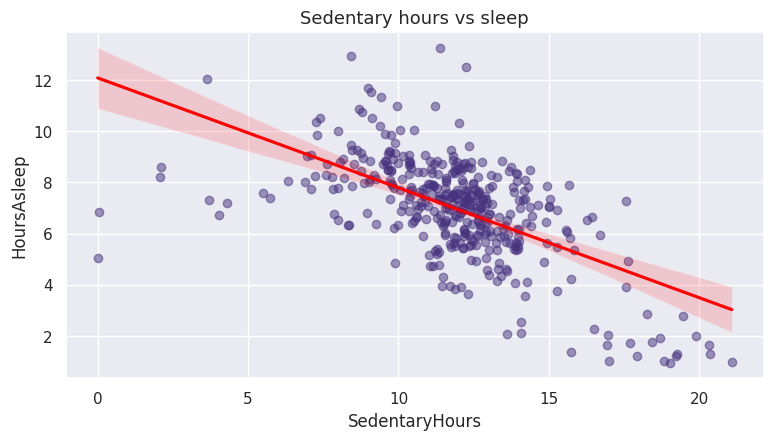

Avg sleep 7.0 h | nights <7h: 44% | efficiency 91.6% | r(sedentary, sleep) = -0.60


In [11]:
sleep["HoursAsleep"] = sleep["TotalMinutesAsleep"] / 60
sleep["Efficiency"] = sleep["TotalMinutesAsleep"] / sleep["TotalTimeInBed"] * 100
sns.histplot(sleep["HoursAsleep"], bins=30, kde=True, color="#4DA6FF"); plt.axvline(7, color="red", ls="--")
plt.title("Hours asleep per night"); plt.show()
mg = daily.merge(sleep, on=["Id","Date"])
sns.regplot(data=mg, x="SedentaryHours", y="HoursAsleep", scatter_kws={"alpha":.5}, line_kws={"color":"red"})
plt.title("Sedentary hours vs sleep"); plt.show()
print(f"Avg sleep {sleep['HoursAsleep'].mean():.1f} h | nights <7h: {(sleep['HoursAsleep']<7).mean()*100:.0f}% | efficiency {sleep['Efficiency'].mean():.1f}% | r(sedentary, sleep) = {mg['SedentaryHours'].corr(mg['HoursAsleep']):.2f}")

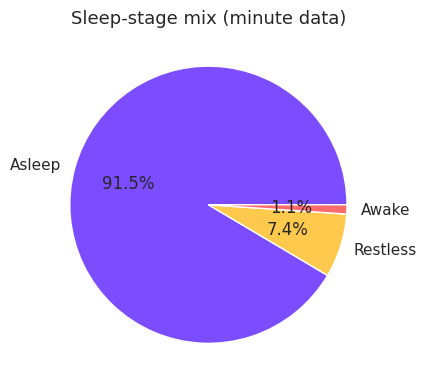

In [12]:
min_sleep["Stage"] = min_sleep["SleepStage"].map({1:"Asleep", 2:"Restless", 3:"Awake"})
min_sleep["Stage"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#7C4DFF","#FFC94D","#FF6B6B"], ylabel="")
plt.title("Sleep-stage mix (minute data)"); plt.show()

## 7. EDA — Heart rate & METs

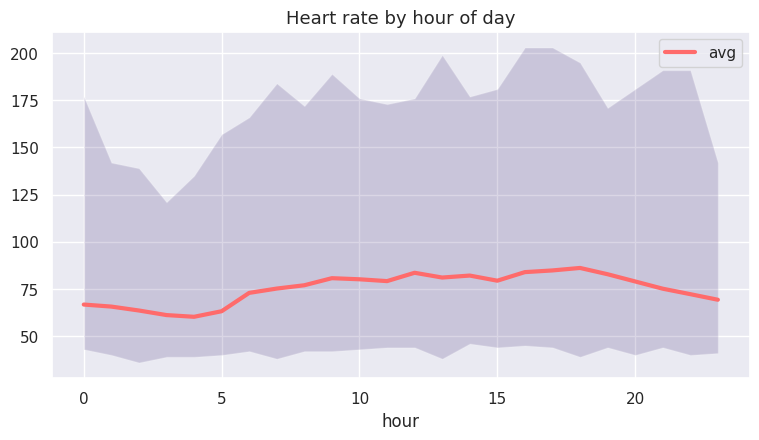

Users with heart-rate data: 14


In [13]:
hr_sec["Hour"] = hr_sec["Time"].dt.hour
hh = hr_sec.groupby("Hour")["Value"].agg(["mean","min","max"])
plt.plot(hh.index, hh["mean"], color="#FF6B6B", lw=3, label="avg"); plt.fill_between(hh.index, hh["min"], hh["max"], alpha=.2)
plt.title("Heart rate by hour of day"); plt.xlabel("hour"); plt.legend(); plt.show()
print("Users with heart-rate data:", hr_sec["Id"].nunique())

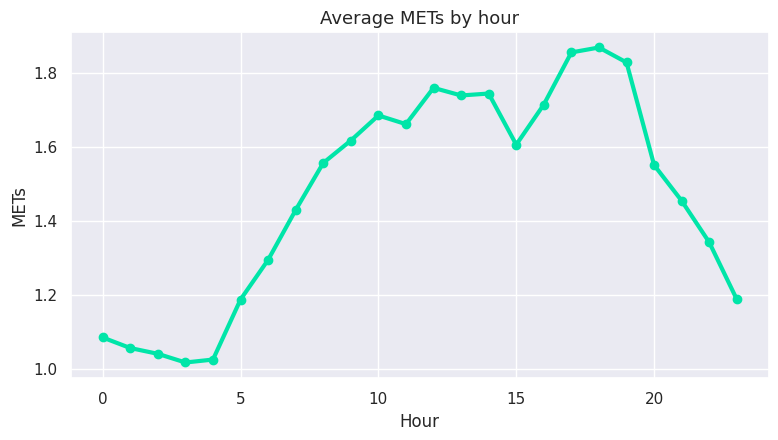

In [14]:
mets["METs"] = mets["METs"] / 10      # dataset stores METs x 10
mets["Hour"] = mets["ActivityMinute"].dt.hour
mets.groupby("Hour")["METs"].mean().plot(color="#00E5A8", lw=3, marker="o"); plt.title("Average METs by hour"); plt.ylabel("METs"); plt.show()

## 8. EDA — Weight

Users logging weight: 8 | entries: 67 | manual: 61%


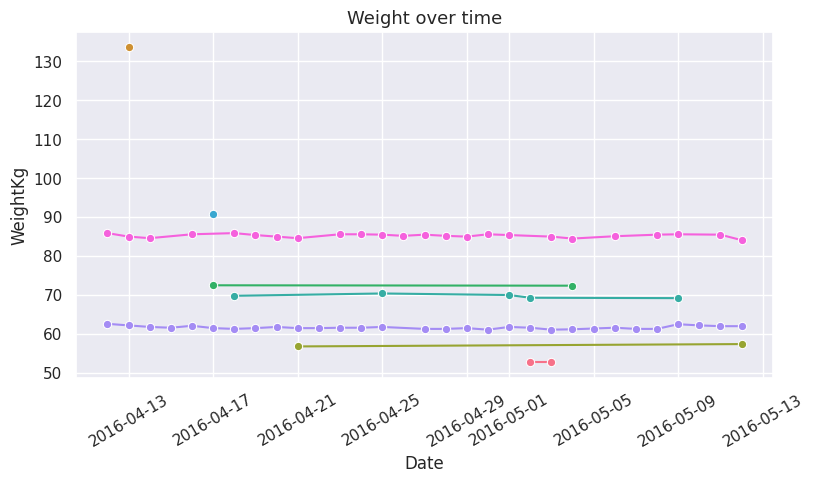

In [15]:
print("Users logging weight:", weight["Id"].nunique(), "| entries:", len(weight), "| manual:", f"{weight['IsManualReport'].mean()*100:.0f}%")
sns.lineplot(data=weight, x="Date", y="WeightKg", hue="Id", marker="o", legend=False); plt.title("Weight over time"); plt.xticks(rotation=30); plt.show()

## 9. SQL analysis (SQLite)

In [16]:
conn = sqlite3.connect("fitbit.db")
for name, df in {"daily_activity": daily.assign(Weekday=daily["Weekday"].astype(str)), "sleep_day": sleep, "weight_log": weight, "hourly": hourly.assign(Weekday=hourly["Weekday"].astype(str))}.items():
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_datetime64_any_dtype(d[c]): d[c] = d[c].dt.strftime("%Y-%m-%d %H:%M:%S")
    d.to_sql(name, conn, index=False, if_exists="replace")
q = lambda s: pd.read_sql_query(s, conn)
q('''SELECT Id, ROUND(AVG(TotalSteps),0) AS avg_steps, ROUND(AVG(Calories),0) AS avg_calories
     FROM daily_activity GROUP BY Id ORDER BY avg_steps DESC LIMIT 10''')

,Id,avg_steps,avg_calories
0,8877689391,16040.0,3420.0
1,8053475328,14763.0,2946.0
2,1503960366,12117.0,1816.0
3,2022484408,11371.0,2510.0
4,7007744171,11323.0,2544.0
5,3977333714,10985.0,1514.0
6,4388161847,10814.0,3094.0
7,6962181067,9795.0,1982.0
8,2347167796,9520.0,2043.0
9,7086361926,9372.0,2566.0


In [17]:
q('''SELECT Weekday, ROUND(AVG(TotalSteps),0) AS avg_steps FROM daily_activity GROUP BY Weekday ORDER BY DayOfWeek''')

,Weekday,avg_steps
0,Monday,7781.0
1,Tuesday,8125.0
2,Wednesday,7559.0
3,Thursday,7406.0
4,Friday,7448.0
5,Saturday,8153.0
6,Sunday,6933.0


In [18]:
q('''SELECT CASE WHEN a.SedentaryMinutes<600 THEN '1) <10h' WHEN a.SedentaryMinutes<900 THEN '2) 10-15h' ELSE '3) 15h+' END AS sedentary_bucket,
            ROUND(AVG(s.TotalMinutesAsleep)/60.0,2) AS avg_hours_asleep, COUNT(*) AS nights
     FROM daily_activity a JOIN sleep_day s ON a.Id=s.Id AND a.Date=s.Date GROUP BY 1 ORDER BY 1''')

,sedentary_bucket,avg_hours_asleep,nights
0,1) <10h,8.61,81
1,2) 10-15h,6.94,292
2,3) 15h+,3.77,37


## 10. Build the `data/` folder for the Streamlit app

In [19]:
daily.drop(columns=["Weekday","SedentaryHours"]).to_csv(f"{OUT}/daily_activity.csv", index=False)
sleep.drop(columns=["HoursAsleep","Efficiency"]).to_csv(f"{OUT}/sleep_day.csv", index=False)
weight.to_csv(f"{OUT}/weight_log.csv", index=False)
hourly.drop(columns=["Weekday"]).to_csv(f"{OUT}/hourly.csv", index=False)

hr_sec["Date"] = hr_sec["Time"].dt.normalize()
hr_sec.groupby(["Id","Date","Hour"])["Value"].agg(AvgHR="mean", MinHR="min", MaxHR="max").reset_index().round(1).to_csv(f"{OUT}/heartrate_hourly.csv", index=False)
hr_sec.groupby(["Id","Date"])["Value"].agg(AvgHR="mean", MinHR="min", MaxHR="max", Readings="count").reset_index().round(1).to_csv(f"{OUT}/heartrate_daily.csv", index=False)

min_sleep.drop(columns=["Stage"]).to_csv(f"{OUT}/minute_sleep.csv", index=False)
mets["Date"] = mets["ActivityMinute"].dt.normalize()
mets.groupby(["Id","Date","Hour"])["METs"].agg(AvgMETs="mean", MaxMETs="max").reset_index().round(2).to_csv(f"{OUT}/mets_hourly.csv", index=False)

pd.DataFrame({"file": sorted(os.listdir(OUT)), "MB": [round(os.path.getsize(f"{OUT}/{f}")/1e6, 2) for f in sorted(os.listdir(OUT))]})

,file,MB
0,daily_activity.csv,0.13
1,heartrate_daily.csv,0.01
2,heartrate_hourly.csv,0.22
3,hourly.csv,1.31
4,mets_hourly.csv,0.73
5,minute_sleep.csv,8.46
6,sleep_day.csv,0.01
7,weight_log.csv,0.01


## Key findings
Numbers upar ke outputs se aate hain — main points:
- Sirf ~1/3 din 10,000 steps tak pahunchte hain; din ka ~80% hissa sedentary hai
- Steps aur calories moderate positive correlation; sedentary time aur sleep negatively correlated
- Heart-rate (14/33) aur weight (8/33) features ka adoption kam hai → onboarding/nudges ka mauka
- Streamlit app chalane ke liye: `streamlit run app.py`